<a href="https://colab.research.google.com/github/farbouw/TM11001-example/blob/main/AIP_segm3_Unet250428.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 1: Deep learning for SegmentationAdvanced Image Processing (TM11005)

Exercise from Lecture: CNNs and Unet for image segmentation

@author: Muhammad Arif


In this exercise, you will learn how to:
   - Prepare your data to be used with a deep learning model.  
   - Write code to build a unet using the deep learning package Keras.
   - Feed data to a deep network as unet and train it.
   - Supervise the learning of the network and how to quantify it.  

## **Handing in your answers**
For each exercise, you have to hand in answers to questions, and
for some also the code. Hence please only hand in two files in total
for this exercise set:

- Code.ipynb: a jupyter notebook containing all the code you are requested to hand in.
- Answers.pdf: a text file with the answers to the
questions (plots, text, ...).

"NOTE: ONLY EXERCISE 5, 6 AND EXERCISE 7 WILL BE GRADED"

## Instruction:
Read Carefully the full CoLab notebook as you move forward. It is important to understand all the steps. If you are in doubt do not hesitate to ask one of tutors.
# Exercise description:

Colab allows you to use a GPU for your computations , which is required for
Neural network models.

For this exercise we will use part of a public data set named PROSTATEX,
this data set was used in a challange to classify prostate cancer tumor according to their  gleasons grade. However, for our learning purposes, we will use it
to train a network that will learn how to do automatic prostate segmentation.

If you want to know more details about this data set you can consult the
following link

https://wiki.cancerimagingarchive.net/display/Public/SPIE-AAPM-NCI+PROSTATEx+Challenges

## Description:

The PROSTATEx Challenge ("SPIE-AAPM-NCI Prostate MR Classification Challenge”)
focused on quantitative image analysis methods for the diagnostic classification
of clinically significant prostate cancers and was held in conjunction with the
2017 SPIE Medical Imaging Symposium (see http://www.spie.org/PROSTATEx/).  PROSTATEx
ran from November 21, 2016 to January 15, 2017, though a "live" version has also
been established at https://prostatex.grand-challenge.org which serves as an ongoing
 way for researchers to benchmark their performance for this task.   

## Install SimpleITK and donwload the data


In [1]:
# we install the packages needed for this practical
!pip install SimpleITK

# We copy the data from a github repository. After runing this command, you will
# inside the tab on your left that some scripst and a folder named "processed".
# This folder contains the image data set organized by patient folder.
! git clone https://github.com/jveenland/TM11005_Unet.git

# Run this part only once.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.3 MB/s eta 0:00:00
Cloning into 'TM11005_Unet'...
remote: Enumerating objects: 1219, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1219 (delta 2), reused 0 (delta 0), pack-reused 1213 (from 1)
Receiving objects: 100% (1219/1219), 58.31 MiB | 29.31 MiB/s, done.
Resolving deltas: 100% (533/533), done.


Import the following packages

In [2]:
# Import neccesary  packages for  the  exercise.
import glob
import os
import numpy as np
from sklearn.model_selection import ShuffleSplit
import SimpleITK as sitk
import matplotlib.pyplot as plt

# Exercise 1 : Getting to Know your data

   Let's get a feeling of the data first. If you check the patient's folder in "TM11005_Unet/processed/"
   you will find two folders; images and their corresponding segmentation.
   Each image correspond to a 2D prostate axial slice.

- Use the SimpleITK package to load a prostate slice from any
   patient and the segmentation belonging to that slice, preferably choose
   for one of the slices of the middle section,for instance: if the
   prostate has 14 slices, load slice 7 or one close to it.
- Plot a figure with a size of 1x3 showing 3 following images:
   - The t2 sequence
   - The mask
   - The segmentation overlay on the t2 / The segmentation contour (your choice)
   - Hint: To show the overlay you may use any function learned during previou exercises. As suggestion , you may choose one of these atributes: pyplot.contour or modifying the color map argument from gray to plt.cm.viridis.

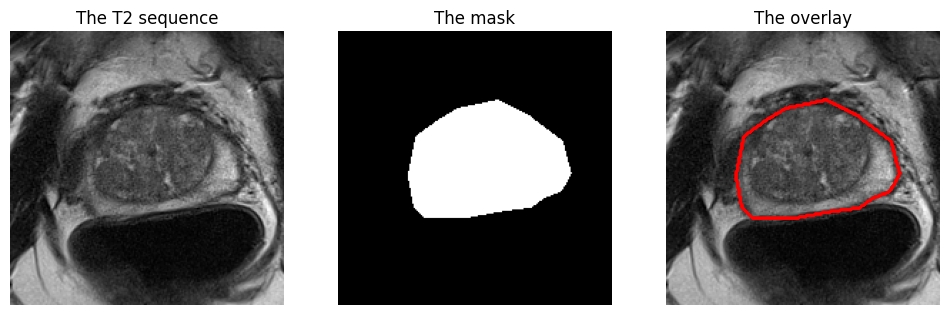

In [3]:
#Excercise 1  Getting to know the data
t2_ima= sitk.ReadImage('/content/TM11005_Unet/processed/ProstateX-0100/images/Px_ProstateX-0100_slice_7.nii')
t2_arr= sitk.GetArrayFromImage(t2_ima)

#code here to read segmentation of same patient and do the plotting
#Get the image of patient 0900 and convert it to an array for plotting
t2_ima_patient0090 =sitk.ReadImage('/content/TM11005_Unet/processed/ProstateX-0090/images/Px_ProstateX-0090_slice_6.nii')
t2_arr_patient0090 = sitk.GetArrayFromImage(t2_ima_patient0090)

#Get the segmentation of patient 0900 and convert it to an array for plotting
t2_mask_patient0090 = sitk.ReadImage('/content/TM11005_Unet/processed/ProstateX-0090/segmentations/Px_ProstateX-0090_slice_6.nii')
t2_arrmask_patient0090 = sitk.GetArrayFromImage(t2_mask_patient0090)

#Make the overlay of the map onto the image, but not used in plotting, only the contour is used
t2_overlay = t2_arr_patient0090 *t2_arrmask_patient0090

#Plotting the t2 sequence, mask and overlay with segmentation contour on the t2 seqeuence
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(t2_arr_patient0090, cmap='gray')
plt.title("The T2 sequence")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(t2_arrmask_patient0090, cmap='gray')
plt.title("The mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(t2_arr_patient0090, cmap='gray')
plt.contour(t2_arrmask_patient0090, colors='r')
plt.title("The overlay")
plt.axis('off')

plt.show()


## Tutorial : improving how you load your data:

   You may have noticed that the data is structured in a specific way. This last
was done  not only with the objective to keep the data organized, but also to
make the data proccessing with python easier. On the following example
you will see how to get advantage of the directory names to locate the images
for patient 100. In this case we are going to use the python module called
"glob", Run the following lines, and understand what  the code is doing.

In [4]:
# First we define our patient (px) data folder
px       = 'ProstateX-0100'
px_fol   = '/content/TM11005_Unet/processed/'

# We define two variables to save the image and segmentation path.
# As you can see , glob list from a specific directory (px_fol) ,
# for a specific patient (px) , all the files (*) that ends as nifti format (nii.)
img_path = glob.glob(px_fol + '/'+px+'/images/*.nii')
seg_path = glob.glob(px_fol + '/'+px+'/segmentations/*.nii')

# Check what is contained in the two variables: img_path and seg_path
print(img_path)
print(seg_path)

['/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_4.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_3.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_10.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_11.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_14.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_7.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_8.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_5.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_9.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_12.nii', '/content/TM11005_Unet/processed//ProstateX-0100/images/Px_ProstateX-0100_slice_6.nii', '/content/TM11005_Unet/proc

# Exercise 2  :  create patient_path_list function:
  -  Write a function called create_px_path that takes a list of patients as input.
  -The function should return  two lists. One list should contain the path
    to the images and the other the paths to the segmentation files.
  - IMPORTANT: check that the ordering inside the two list corresponds to the same image and segmentation. For instance, if the first element in the images list corresponds to patient 100 slice 8. Then,the first element of the segmentation list should correspond to patient 100, slice 8 as well.

In [5]:
from re import X
#Exercise 2
#Function for patient path of image and segmentation

def create_px_path(px_list):
  #Define data folder
  px_fol   = '/content/TM11005_Unet/processed/'
  #Empty lists for saving the paths
  x_imag = []
  y_segm = []

  #Loop over all patients in the list
  for px in px_list:
    #Search for all image and segmentation files (.nii) in the folders
    img_paths = glob.glob(px_fol + '/'+px+'/images/*.nii')
    seg_paths = glob.glob(px_fol + '/'+px+'/segmentations/*.nii')
    #Sort both the lists, such that image and mask remain together in the correct order
    img_paths.sort()
    seg_paths.sort()
    x_imag.extend(img_paths)
    y_segm.extend(seg_paths)
  return x_imag, y_segm

## Check-point

Run the following code to check the result of Exercise 2

In [6]:
# Check-POINT if you did the previous exercise correctly , this function should't
# give an error. IF you do get an error, you must go back and fix your code

def check_fun(x_path):

    samp_lis , _= create_px_path(x_path)
    print(samp_lis)
    if not samp_lis:
        raise('your create_px_path function is returning an empty list')

    for sam in samp_lis:
        print(sam)
        if isinstance(sam,list):
           raise('The output of your create_px_path function is wrong, it returns as output a list with more lists inside...')
    return


check_fun(os.listdir(px_fol))

['/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_10.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_11.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_12.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_13.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_14.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_15.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_16.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_17.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_18.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_19.nii', '/content/TM11005_Unet/processed//ProstateX-0039/images/Px_ProstateX-0039_slice_20.nii', '/content/TM11005_Un

# Exercise 3 data Normalization:
In order to reduce the data differences, let's perform a data normalization   using the following formula:

         norm_imag = image - percentile_05 / (percentile_95 - percentile_5)

- Define a percentile_norm function that takes an image array as
     input and return the image data normalized using the previous formula.
     The goal here is to set all the images intensities in the same range from
     (0 to 1).
     HINT
     Read the np.percentile function documentation to know how to obtain the 90th
     and 10th percentile with numpy.

  -To check that your function is working properly, plot a 2x3 figure, the first row should contain 3 random prostate slices, the second row will      contain the sames images after being normalized.
-Even the images intensities where modified in terms of their range, you shall see that they visually are still the same.
     
     Foundation:
     - The idea behind normalizing the data is related to the fact that a learning
       algorithm (Unet in our case), will use the image intensities to create kernels
       with features to learn the segmentation. If there are many differences between
       images intensities, finding common kernels for all the images would be a
       intensive task because the feature space will be too broad. Resulting in a long
       learning process and decreasing the chances of reaching a global minimum.

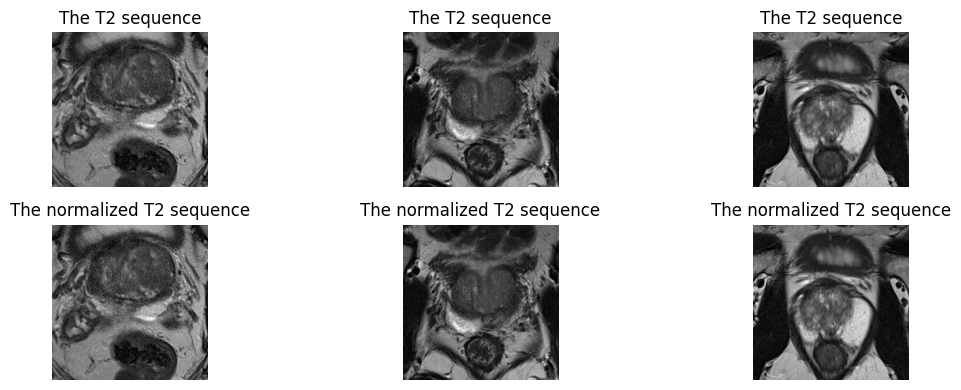

In [7]:
np.random.seed(180)   #Do not modify this line , it is for reproducibility.

images,_ = create_px_path(os.listdir(px_fol))
def percentile_norm(datas):
    #Determine the 5th and 95th percentile
    x_95  = np.percentile(datas,95)
    x_05  = np.percentile(datas,5)
    #Substract x_05 such that x_05 = 0
    datas = datas - x_05
    #Divide by the range, such that x_95 = 1
    datas  /= (x_95 - x_05)

    return datas

# Code here
#Choose 3 random images
three_random_images = np.random.choice(images, 3, replace=False)
plt.figure(figsize=(12,4))
#Loop over the 3 random images
for i, image in enumerate(three_random_images):
  image_data = sitk.ReadImage(image)
  image_data_arr = sitk.GetArrayFromImage(image_data)
  #Normalize the image to range 0-1
  image_data_norm = percentile_norm(image_data_arr.copy())

  #Plot the image
  plt.subplot(2,3,i+1)
  plt.imshow(image_data_arr, cmap='gray')
  plt.title("The T2 sequence")
  plt.axis('off')

  #Plot the normalized image
  plt.subplot(2,3,i+4)
  plt.imshow(image_data_norm, cmap='gray')
  plt.title("The normalized T2 sequence")
  plt.axis('off')
plt.tight_layout()
plt.show()



## Tutorial: Splitting the data
  In this part of the code we define a function that split our patient
  data into training, validation and test. The function takes a list of patient
  names and randomly split it. First into training and test, then the training
  is split into training and validation. In each iteration we take 20% of the patient data. The function returns a data dictionary with the names of the patient on each set.

In [8]:
#https://medium.com/@shivamrawat_756/how-to-prevent-google-colab-from-disconnecting-717b88a128c0

def split_data_train_val_test(px_fol):

    patients = os.listdir(px_fol)
    patients = np.asarray(patients)

    ss    = ShuffleSplit(n_splits=1,test_size=0.20)
    ss.get_n_splits(patients)
    for train_index, test_index in ss.split(patients):
        xt, x_test = patients[train_index], patients[test_index]

    ss = ShuffleSplit(n_splits=1, test_size=0.20)
    ss.get_n_splits(xt)
    for ten_index, val_index in ss.split(xt):
        x_train_in, x_val_in= xt[ten_index], xt[val_index]

    px_splits = {'train': np.ndarray.tolist(x_train_in),
                 'val'  : np.ndarray.tolist(x_val_in)  ,
                 'test' : np.ndarray.tolist(x_test)    }

    return px_splits

px_fol_path = '/content/TM11005_Unet/processed/'
px_split_di = split_data_train_val_test(px_fol_path)



# Exercise 4:
   While training the network, we will need to provide the patients data paths.
   Therefore, we need to obtain the path to each patient and their images.
   
   - Use your create_px_path function from exercise 2 to generate the paths of each set.
   - You will have to provide an image dictionary per set (x_train/val/test) and a segmentation dictionary (y_train /val /test).
   - We use the x and y as a convention in machine learning for training data (x) and target/label data
   (y).

In [9]:
x_train , y_train = create_px_path(px_split_di['train'])
x_valid , y_valid = create_px_path(px_split_di['val'])
x_test  , y_test  = create_px_path(px_split_di['test'])

##     Tutorial: Batch generator

  These functions allow us to create a batch of data that is going to be
    feeaded to Unet , one for the images and other for the segmentations. The
    only difference is the noramlization for the t2 images, which is not
    required for the segmentation image.

In [10]:
""" DO NOT MODIFY """
def generate_batch_norm(batch):
    data = []

    for img in batch:
        #print('img = '+str(img))
        img_data = sitk.ReadImage(img)

        img_data = sitk.GetArrayFromImage(img_data)
        img_data = img_data.astype('float32')
        img_data = percentile_norm(img_data)
        data.append(img_data)

    data = np.stack(data)


    data = np.reshape(data, (data.shape[0],data.shape[2],data.shape[1],1))
    return data

def generate_batch(batch):
    data = []

    for img in batch:
        #print('img = '+str(img))
        img_data = sitk.ReadImage(img)

        img_data = sitk.GetArrayFromImage(img_data)
        img_data = img_data.astype('float32')
        data.append(img_data)

    data = np.stack(data)


    data = np.reshape(data, (data.shape[0],data.shape[2],data.shape[1],1))
    return data



  ## Tutorial Data Generator
Example Data generator: This function is made to generate a image batch. Neural networks consume a lot
   of computing resources, therefore to train a network like U-net we feed it with
   smaller portions of data, a data batch. This function takes a list of patient
   image paths , image targets and the desired batch size. As you can see, the
   end of the function finish with the word "yield" instead of return. This means
   that the local variables will be kept while the condition of the function is
   true, this kind of statement is used to return intermediate results.
   In other words, we can keep "feeding" the Unet with data continuously, by providing
   data batches until we reach to the end of the image list (while
   the function is called by the network).

In [11]:
"""DO NOT MODIFY

"""
def data_feeder(x_lis,y_tar,d_size):
    while True:
        len_lis = len(x_lis)
        nu_part = int(np.ceil(len_lis / d_size))
        count   = 0

        for i in range(nu_part):

            current_batch_size = min(d_size, len_lis - count)

            p_list  = x_lis[count:count + current_batch_size]
            segment = y_tar[count:count + current_batch_size]

            images = generate_batch_norm(p_list)
            target = generate_batch(segment)
            count += current_batch_size
            if images.shape[0] == d_size:
                yield images, target

 ##  Dice coefficient formula:
   To compute the error during learning process we will use the dice
   coefficient. Every time the network performs a prediction (y_pred = segmentation prediction),
   this new predicted image will be compared with the ground truth (y_true). Then,
   based on this error value, the network will update its parameters in order to improve
   the prediction for the next time it sees a new example. This process occurs mathematically
   using differential equations. Therefore, we need define the dice function using tensors,
   which allow us to compute the derivatives in python.

In [12]:
"""DO NOT MODIFY
"""
from tensorflow.keras import backend as K

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(y_true,[-1])
    y_pred_f = tf.reshape(y_pred,[-1])
    intersection = K.sum(y_true_f * y_pred_f)
   # K.print_tensor(intersection, message="Dice intersection:")
    return -((2. * intersection + K.epsilon()) / (K.sum(y_true_f)
                                                  + K.sum(y_pred_f)
                                                  + K.epsilon()))

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

# Exercise 5:  Define Unet using keras:

On this part you will have to complete the code to  define unet. Given that the original unet request many computational resources, we will define a slightly simpler unet. As you can see most of the code is written already, you will need to use the image provided for this practical **model_exercise.png**
   to complete the code.
  - The parts that specifically requires your input are marked like this:
   'x,x '.

  - Define the input layer according to your image size and color channels    (height, width, channels)   

  - For the convolution layers  you must define ONLY
     the number of kernels and a kernel  size =  3. The size of input
     and output is taken care by tensorflow and keras.

  - Define the Max pooling layers using a pooling of 2x2

  - For the upsampling layers you will need a kernel size = 2.


  - Notice that the number of kernels is doubled on each convoultional layer
     while the kernel size is kept the same.

  - HINT: you may use keras documentation to help you with the code:
       https://keras.io/layers/convolutional/

  - When the model is finished, run the line create_unet.   

In [13]:
print(generate_batch_norm(x_train[:1]).shape)

(1, 192, 192, 1)


In [14]:
!pip install Keras-Preprocessing

!pip install Keras-Preprocessing
import tensorflow as tf
from keras import Input
from keras.models import Model
from keras.layers import MaxPooling2D, UpSampling2D, Dropout
from tensorflow.keras.optimizers import Adam
from keras.layers import Concatenate, Conv2D
from keras_preprocessing.image import array_to_img
from keras.callbacks import ModelCheckpoint

# import tensorflow.compat.v1 as tf
# tf.disable_v2_behavior()
# from tf.keras.utils import plot_model

def create_unet():

    # Create a U-Net

    print('Creating U-Net...')

    #First, we have to provide the dimensions of the input images
    #This is (192,192,1), because I printed the
    inputs = Input((192,192,1))

    conv1 = Conv2D(32,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(inputs)
    conv1 = Conv2D(32,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)


    print('conv1 shape:', conv1.shape)
    print('pool1 shape:', pool1.shape)

    conv2 = Conv2D(64,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(pool1)
    conv2 = Conv2D(64,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    print('conv2 shape:', conv2.shape)
    print('pool2 shape:', pool2.shape)


    conv3 = Conv2D(128,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(pool2)
    conv3 = Conv2D(128,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv3)
    drop4 = Dropout(0.5)(conv3)  # Added
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)


    print('conv3 shape:', conv3.shape)
    print('pool3 shape:', pool3.shape)

    conv4 = Conv2D(256,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(pool3)
    conv4 = Conv2D(256,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)

    print('conv4 shape:', conv4.shape)


    up7 = Conv2D(128,2 , activation='relu', padding='same',
                 kernel_initializer='he_normal')(
                         UpSampling2D(size=(2, 2))(drop4))  # Changed
    merge7 = Concatenate(axis=3)([conv3, up7])
    conv7 = Conv2D(128,3 ,activation='relu', padding='same',
                   kernel_initializer='he_normal')(merge7)
    conv7 = Conv2D(128,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv7)
    print('conv7 shape:', conv7.shape)

    up8 = Conv2D(64,2 , activation='relu', padding='same',
                 kernel_initializer='he_normal')(
                         UpSampling2D(size=(2, 2))(conv7))
    merge8 = Concatenate(axis=3)([conv2, up8])
    conv8 = Conv2D(64,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(merge8)
    conv8 = Conv2D(64,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv8)
    print('conv8 shape:', conv8.shape)

    up9 = Conv2D(32,2 , activation='relu', padding='same',
                 kernel_initializer='he_normal')(
                         UpSampling2D(size=(2, 2))(conv8))
    merge9 = Concatenate(axis=3)([conv1, up9])
    conv9 = Conv2D(32,3 ,activation='relu', padding='same',
                   kernel_initializer='he_normal')(merge9)
    conv9 = Conv2D(32,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv9)
    conv9 = Conv2D(32,3 , activation='relu', padding='same',
                   kernel_initializer='he_normal')(conv9)
    print('conv9 shape:', conv9.shape)

    conv10 = Conv2D(1, 1, activation='sigmoid')(conv9)
    print('conv10 shape:', conv10.shape)

    model = Model(inputs=inputs, outputs=conv10)

    model.compile(optimizer='adam',
                  loss=dice_coef, metrics=[dice_coef_loss])



    print('Got U-Net!')

    return model

model = create_unet()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.5 MB/s eta 0:00:00
Creating U-Net...
conv1 shape: (None, 192, 192, 32)
pool1 shape: (None, 96, 96, 32)
conv2 shape: (None, 96, 96, 64)
pool2 shape: (None, 48, 48, 64)
conv3 shape: (None, 48, 48, 128)
pool3 shape: (None, 24, 24, 128)
conv4 shape: (None, 24, 24, 256)
conv7 shape: (None, 48, 48, 128)
conv8 shape: (None, 96, 96, 64)
conv9 shape: (None, 192, 192, 32)
conv10 shape: (None, 192, 192, 1)
Got U-Net!


## Tutorial : Training Unet


   In this section we start training Unet. First we define a number of epochs,
   which is  the number of times that Unet is going to "observe"
   the whole training set, and learn from it the features to perform the segmentation.
   We also define a batch size of 4, which is the number of samples the network
   is going to "see" at the same time. The bigger the number of batches, less
   time will take the network to complete an epoch. However, as the number
   of batches is increased, more RAM is required.


In [15]:
epch = 80
batch_size = 4

#Here we define where to save the network parameters (weights)
filepath='/content/TM11005_Unet/weights_nw/w_epoch_.{epoch:03d}_'+'.keras'

# To keep track of the learning process we use checkpoints, as you see in the
  #  code, every 15 epochs we are going to save the parameters of the network(weights).
  #  Therefore, we can restart the network on a earlier stage to compare the
  #  performance with the latest ones. This function is also useful in order
  #  to make a saving point in case our code fails, you can restart the training from
  #  one of this checkpoints, so the network doesn't need to start learning
  #  from the beginning.


  #  IMPORTAN WARNING: WHEN YOU START RUNNING THIS SECTION

  #  When the model training is finished, we are going to plot the training
  #  history in the following section.

#We define our check point based on the dice_coef_loss and check it every 5 epochs

checkpoint = ModelCheckpoint(filepath, monitor='val_dice_coef_loss',save_freq=83*5, verbose=1, save_best_only=False,
                              mode='max')

callbacks_list = [checkpoint]

  #  Keras package allow us to train the model using the attribute "fit_generator",
  #  we give as input the data generator previously defined, we also define what
  #  data is going to be used for training and validation. In history we are going
  #  to save all the training process.


  #     Run this part of the code, each epoch should take approximately 3-6 seconds,
  #  the code will run for 250 epochs. Therefore, you can take this tame to have a
  #  short coffee brake. After the training is complete, continue with the next
  #  section.


train_dataset = tf.data.Dataset.from_generator(
    lambda: data_feeder(x_train, y_train, batch_size),
    (tf.float32, tf.float32),
    (tf.TensorShape([batch_size, 192, 192, 1]), tf.TensorShape([batch_size, 192, 192, 1]))
)

validation_dataset = tf.data.Dataset.from_generator(
    lambda: data_feeder(x_valid, y_valid, batch_size),
    (tf.float32, tf.float32),
    (tf.TensorShape([batch_size, 192, 192, 1]), tf.TensorShape([batch_size, 192, 192, 1]))
)

history=model.fit(
    train_dataset,
    steps_per_epoch=len(x_train) // batch_size,
    epochs=epch,
    validation_data=validation_dataset,
    validation_steps=len(x_valid) // batch_size,
    callbacks=callbacks_list
)

# WARNING ....IMPORTANT......WARNING:

#     Colab after some minutes of inactivity will erase your session. Therefore,
#     all the data, and the weights generated by the network during the training
#     will be removed. To avoid losing your progress, you can run the code below, this will
#     start  downloading the files obtained during your exercise,
#     save them in your local drive.
#

import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from google.colab import files
import shutil

pd.to_pickle(history,'/content/TM11005_Unet/epochs_history')
files.download('/content/TM11005_Unet/epochs_history')

#Save and download all model weights

shutil.make_archive(
    '/content/weights_backup',
    'zip',
    '/content/TM11005_Unet/weights_nw'
)

files.download('/content/weights_backup.zip')


Epoch 1/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - dice_coef_loss: 0.2632 - loss: -0.2632 - val_dice_coef_loss: 0.3798 - val_loss: -0.3798
Epoch 2/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - dice_coef_loss: 0.4281 - loss: -0.4281 - val_dice_coef_loss: 0.4773 - val_loss: -0.4773
Epoch 3/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - dice_coef_loss: 0.4990 - loss: -0.4990 - val_dice_coef_loss: 0.4923 - val_loss: -0.4923
Epoch 4/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - dice_coef_loss: 0.5979 - loss: -0.5979 - val_dice_coef_loss: 0.6057 - val_loss: -0.6057
Epoch 5/80
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - dice_coef_loss: 0.6310 - loss: -0.6310
Epoch 5: saving model to /content/TM11005_Unet/weights_nw/w_epoch_.005_.keras

Epoch 5: finished saving model to /content/TM11005_Unet/weights_nw/w_epoch_.005_.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - dice_coef_loss: 0.4424 - loss: -0.4424 - val_dice_coef_loss: 4.7001e-12 - val_loss: -4.7001e-12
Epoch 6/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.colab import files
files.download('/content/TM11005_Unet/epochs_history')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#   Plot your loss function graph


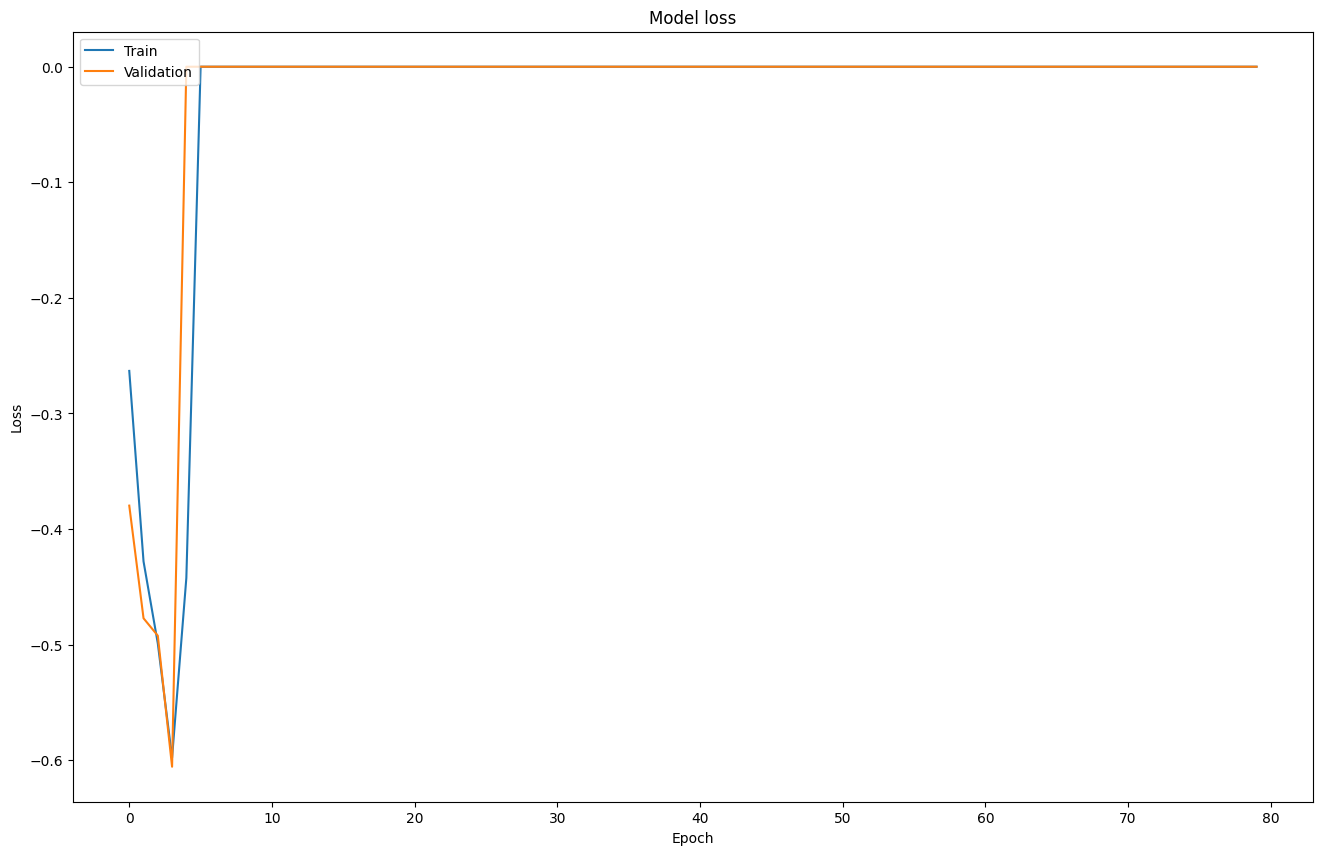

In [17]:
from datetime import datetime
now = datetime.now()
date_time = now.strftime("%m_%d_%Y_%H:%M:%S")
plt.figure(figsize=(16,10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/TM11005_Unet/model_loss_'+str(date_time)+'.png')
plt.show()


In [18]:
# Download your loss function graph#

from google.colab import files
files.download('/content/TM11005_Unet/model_loss_'+str(date_time)+'.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exercise 6: Explain the Loss Function
Look at the graph, and answer the following

- What is the relationship between the training loss and the validation loss?

- How would you use this graph to decide until what point is reasonable to
     train the network? and why?

- How can you improve the validation loss and what parameters you can tune.

Try those optimization steps and show your traning-validation loss curve.

Creating U-Net...
conv1 shape: (None, 192, 192, 32)
pool1 shape: (None, 96, 96, 32)
conv2 shape: (None, 96, 96, 64)
pool2 shape: (None, 48, 48, 64)
conv3 shape: (None, 48, 48, 128)
pool3 shape: (None, 24, 24, 128)
conv4 shape: (None, 24, 24, 256)
conv7 shape: (None, 48, 48, 128)
conv8 shape: (None, 96, 96, 64)
conv9 shape: (None, 192, 192, 32)
conv10 shape: (None, 192, 192, 1)
Got U-Net!
Epoch 1/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - dice_coef_loss: 0.4355 - loss: -0.4355 - val_dice_coef_loss: 0.5199 - val_loss: -0.5199
Epoch 2/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - dice_coef_loss: 0.5796 - loss: -0.5796 - val_dice_coef_loss: 0.5994 - val_loss: -0.5994
Epoch 3/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - dice_coef_loss: 0.6551 - loss: -0.6551 - val_dice_coef_loss: 0.6468 - val_loss: -0.6468
Epoch 4/80
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - dice_coef_loss: 0.6598 - loss: -0.6598 - val_dice_coef_loss: 0.6442 - val_loss: -0.6442
Epoch 5/80
67/83 ━━━━━━━━━━━━━━━━━━━━ 0s 55m

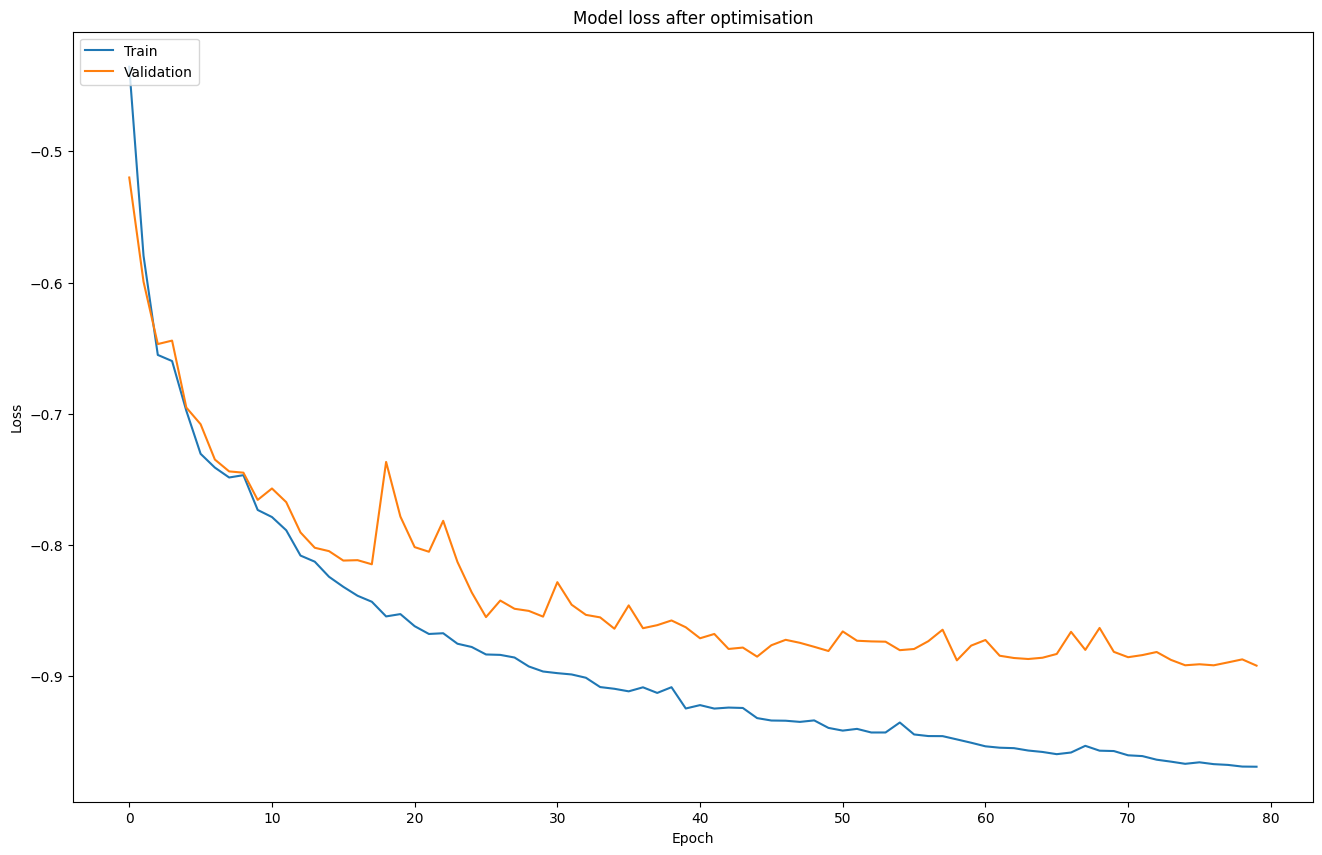

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
#Changed the learning rate from 0.001 to 0.0001 to check if this changes the traning-validation loss curve. A lower learning curve allows to find smaller improvements.
os.makedirs('/content/TM11005_Unet/weights_nw_lr', exist_ok=True)

filepath = '/content/TM11005_Unet/weights_nw_lr/w_epoch_.{epoch:03d}_.keras'

checkpoint_lr = ModelCheckpoint(
    filepath,
    monitor='val_dice_coef_loss',
    save_freq=80*5,   # of 83*5 als dat jouw steps_per_epoch is
    verbose=1,
    save_best_only=False,
    mode='max'
)

callbacks_list_lr = [checkpoint_lr]

epch = 80
batch_size = 4

model = create_unet()

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=dice_coef, metrics=[dice_coef_loss])

train_dataset = tf.data.Dataset.from_generator(
    lambda: data_feeder(x_train, y_train, batch_size),
    output_types=(tf.float32, tf.float32),
    output_shapes=(tf.TensorShape([batch_size, 192, 192, 1]), tf.TensorShape([batch_size, 192, 192, 1]))
)

validation_dataset = tf.data.Dataset.from_generator(
    lambda: data_feeder(x_valid, y_valid, batch_size),
    output_types=(tf.float32, tf.float32),
    output_shapes=(tf.TensorShape([batch_size, 192, 192, 1]),tf.TensorShape([batch_size, 192, 192, 1]))
)

history_opt = model.fit(
    train_dataset,
    steps_per_epoch=len(x_train) // batch_size,
    epochs=epch,
    validation_data=validation_dataset,
    validation_steps=len(x_valid) // batch_size,
    callbacks=callbacks_list_lr
)

plt.figure(figsize=(16,10))
plt.plot(history_opt.history['loss'])
plt.plot(history_opt.history['val_loss'])
plt.title('Model loss after optimisation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

pd.to_pickle(history_opt.history, '/content/history_lr')
files.download('/content/history_lr')


shutil.make_archive(
    '/content/weights_lr0001',
    'zip',
    '/content/TM11005_Unet/weights_nw_lr'
)

files.download('/content/weights_lr0001.zip')


Creating U-Net...
conv1 shape: (None, 192, 192, 32)
pool1 shape: (None, 96, 96, 32)
conv2 shape: (None, 96, 96, 64)
pool2 shape: (None, 48, 48, 64)
conv3 shape: (None, 48, 48, 128)
pool3 shape: (None, 24, 24, 128)
conv4 shape: (None, 24, 24, 256)
conv7 shape: (None, 48, 48, 128)
conv8 shape: (None, 96, 96, 64)
conv9 shape: (None, 192, 192, 32)
conv10 shape: (None, 192, 192, 1)
Got U-Net!
Epoch 1/80
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - dice_coef_loss: 0.2623 - loss: -0.2623 - val_dice_coef_loss: 9.8185e-12 - val_loss: -9.8185e-12
Epoch 2/80
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - dice_coef_loss: 3.2060e-07 - loss: -3.2060e-07 - val_dice_coef_loss: 9.8185e-12 - val_loss: -9.8185e-12
Epoch 3/80
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - dice_coef_loss: 2.4281e-07 - loss: -2.4281e-07 - val_dice_coef_loss: 9.8185e-12 - val_loss: -9.8185e-12
Epoch 4/80
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - dice_coef_loss: 3.0847e-07 - loss: -3.0847e-07 - val_dice_coef_loss: 9.8185e-12 - va

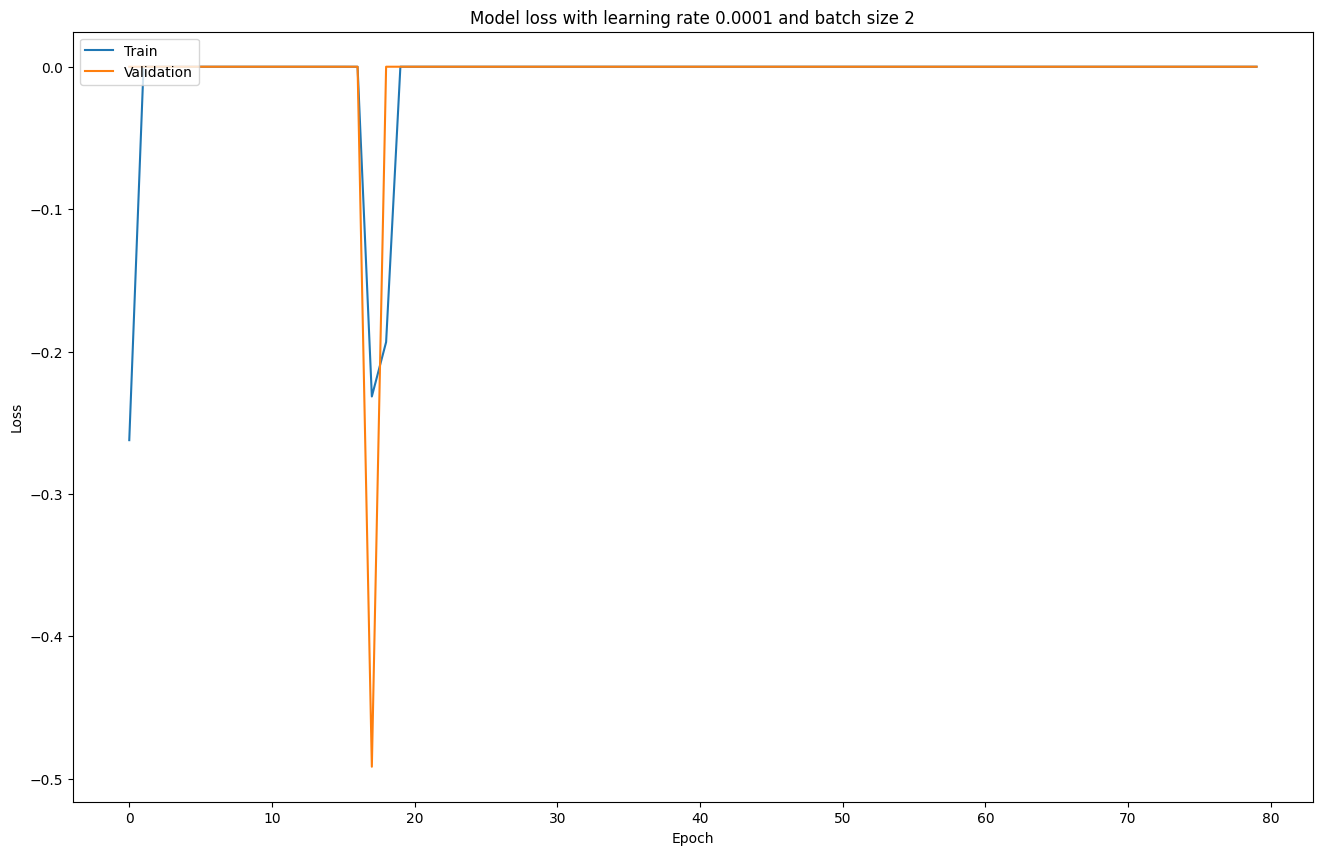

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: [Errno 2] No such file or directory: '/content/TM11005_Unet/weights_nw_bs2'

In [20]:
#Second optimisation: change batch size from 4 to 2
os.makedirs('/content/TM11005_Unet/weights_bs2',
            exist_ok=True)

epch = 80
batch_size = 2

train_dataset_bs2 = tf.data.Dataset.from_generator(
    lambda: data_feeder(x_train, y_train, batch_size),
    output_types=(tf.float32, tf.float32),
    output_shapes=(tf.TensorShape([batch_size, 192, 192, 1]),tf.TensorShape([batch_size, 192, 192, 1]))
)

validation_dataset_bs2 = tf.data.Dataset.from_generator(
    lambda: data_feeder(x_valid, y_valid, batch_size),
    output_types=(tf.float32, tf.float32),
    output_shapes=(tf.TensorShape([batch_size, 192, 192, 1]),tf.TensorShape([batch_size, 192, 192, 1]))
)

model_bs2 = create_unet()

model_bs2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=dice_coef, metrics=[dice_coef_loss]
)

history_bs2 = model_bs2.fit(
    train_dataset_bs2,
    steps_per_epoch=len(x_train) // batch_size,
    epochs=80,
    validation_data=validation_dataset_bs2,
    validation_steps=len(x_valid) // batch_size
)

plt.figure(figsize=(16,10))
plt.plot(history_bs2.history['loss'])
plt.plot(history_bs2.history['val_loss'])
plt.title('Model loss with learning rate 0.0001 and batch size 2')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

pd.to_pickle(history_opt.history, '/content/history_bs2')
files.download('/content/history_bs2')

shutil.make_archive(
    '/content/weights_bs2',
    'zip',
    '/content/TM11005_Unet/weights_bs2'
)

files.download('/content/weights_bs2.zip')

## Tutorial: How the model behaves with unseen data.
   
   So far we have an idea how the model will perform with the training and validation
   data. Additionally , we can use the graph to decide which parameters works
   better for our validation data. Nevertheless, in real life situations we do
   not have ground thruth. Therefore, to prove that our estimation is correct
   we need to test our model with data that was not used at all to build our
   network on the first place.

   In the following example We will load a patient from the test set, make an
   automatic segmentation with the network and compare the result with the
   ground truth segmentation. According to out graph we should select a set of
   weights obtained after epoch 72, from this we could expect a dice coeficent  
   around 0.8.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
dice = 0.0


(<Axes: title={'center': 'Dice = 0.0'}>,
 <matplotlib.image.AxesImage at 0x7808da657560>)

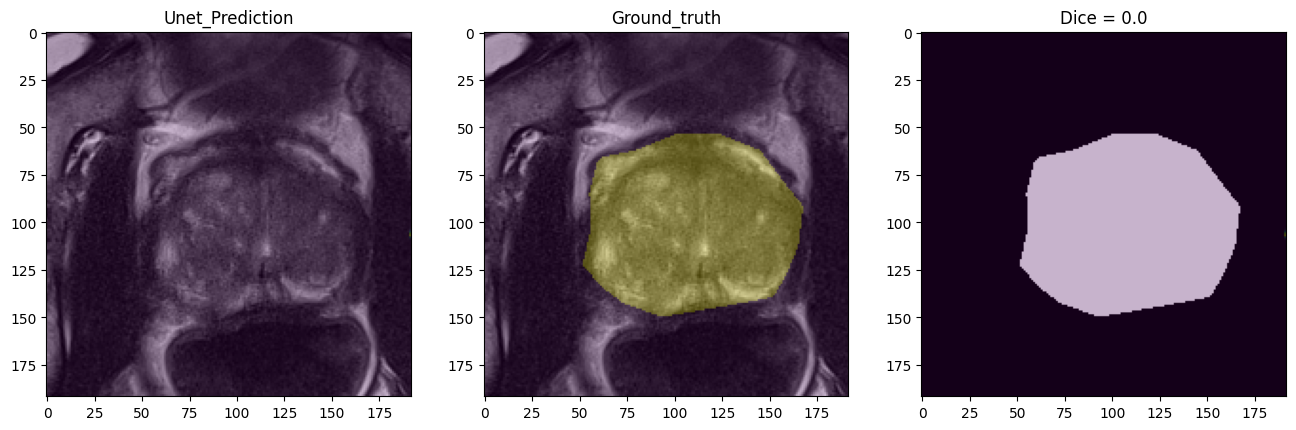

In [22]:
# First we load a prostate slice from the test set
#model =  create_unet()

im_arra= generate_batch_norm([x_test[6]])

# Then we  load a set of weights that theoretically will give us a good
# performance. The weights were save during the training process in the
# weights_new folder.

model.load_weights('/content/TM11005_Unet/weights_nw/w_epoch_.075_.keras')

# Now that the networks has loaded the weights from the desired epoc, we
# perfom a prediction on the slice.

mask_pred = model.predict(im_arra)

# The network requires the input to be (1x height x lengh x 1), however
# in order to visualize it , we need to  change it to a 2d array.
mask_pred = mask_pred [0,:,:,0]

# Then we load then ground thruth for that slice.
y_target = sitk.ReadImage(y_test[6])
y_target = sitk.GetArrayFromImage(y_target)


# We define a dice coefficent fuction :

def computeDice(reference, automatic):
    return 2*(np.sum(reference*automatic))/(np.sum(reference)+np.sum(automatic))

# Compute the dice and plot the images to compare
dice=str(computeDice(y_target,mask_pred))
print('dice = '+ str(computeDice(y_target,mask_pred)))


# Let's visualize the result on the test image
plt.figure(figsize=(16,10))
plt.subplot(1,3,1),plt.imshow(im_arra[0,:,:,0],cmap='gray'),plt.title('Unet_Prediction')
plt.subplot(1,3,1),plt.imshow(mask_pred,cmap=plt.cm.viridis,alpha=.3)

plt.subplot(1,3,2),plt.imshow(im_arra[0,:,:,0],cmap='gray'),plt.title('Ground_truth')
plt.subplot(1,3,2),plt.imshow(y_target,cmap=plt.cm.viridis,alpha=.3)

plt.subplot(1,3,3),plt.imshow(y_target,cmap='gray'),plt.title('Dice = '+dice)
plt.subplot(1,3,3),plt.imshow(mask_pred,cmap=plt.cm.viridis,alpha=.3)


# As you can see we achieve a "decent" result on one test example. Futhermore,
# small details should be corrected in a post-processing phase. Nevertheless,
# the network has learned some features to manage the segmentation in unseen
# data.

 # Exercise 7: Visualize and quantify the learning process
 Select a prostate slice from the test set and make a prediction with the
  network using 4 sets of weights.
- Select the weights using the loss function figure as reference, you should select4 weight files that theoretically should increase the performance of the network in increasing order (from the worst to the best).

- Create a figure showing the  network prediction, overlapped on the the original image, including the weights file on the title.

- Plot the ground truth overlayed on the original image

- At the end your figure size will be 1x5, each plot showing the network prediction on the original image, identified with the weights title.

- Comment your results by answering the following questions:

  -Did the weight selection worked according to your graph?

  -Can you see the network performance improving during the time?
      
   -Did you get a worse result with the last set of weights? if yes, what     could be the reason behind this?

['w_epoch_.029_.keras', 'w_epoch_.039_.keras', 'w_epoch_.010_.keras', 'w_epoch_.063_.keras', 'w_epoch_.034_.keras', 'w_epoch_.005_.keras', 'w_epoch_.054_.keras', 'w_epoch_.044_.keras', 'w_epoch_.049_.keras', 'w_epoch_.068_.keras', 'w_epoch_.025_.keras', 'w_epoch_.058_.keras', 'w_epoch_.015_.keras', 'w_epoch_.073_.keras', 'w_epoch_.078_.keras', 'w_epoch_.020_.keras']
Creating U-Net...
conv1 shape: (None, 192, 192, 32)
pool1 shape: (None, 96, 96, 32)
conv2 shape: (None, 96, 96, 64)
pool2 shape: (None, 48, 48, 64)
conv3 shape: (None, 48, 48, 128)
pool3 shape: (None, 24, 24, 128)
conv4 shape: (None, 24, 24, 256)
conv7 shape: (None, 48, 48, 128)
conv8 shape: (None, 96, 96, 64)
conv9 shape: (None, 192, 192, 32)
conv10 shape: (None, 192, 192, 1)
Got U-Net!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
0.0 0.99999046 0.3048456
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
0.0 1.0 0.27917707
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
0.0 1.0 0.2790662
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
0.0 1.0 0.27642554


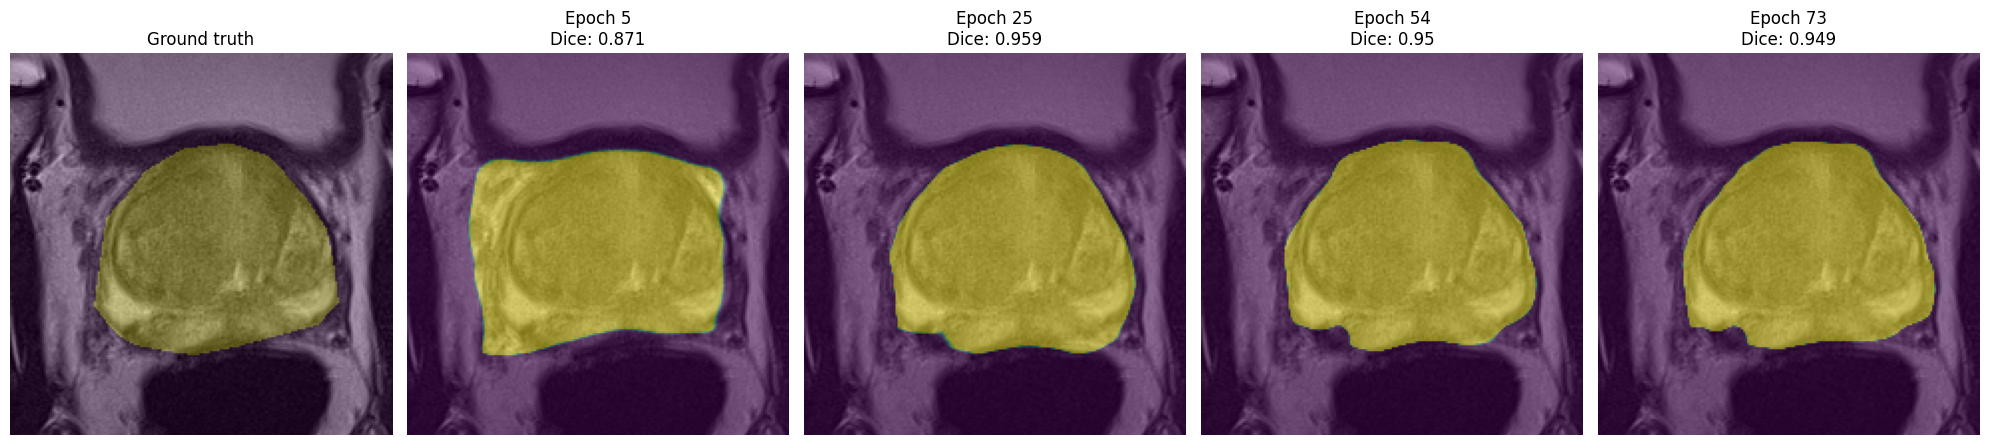

In [24]:
import zipfile

with zipfile.ZipFile('/content/weights_lr0001.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/weights_lr0001')

np.random.seed(6)
# write your code here
import os
#print(os.listdir('/content/TM11005_Unet/weights_nw/'))
print(os.listdir('/content/TM11005_Unet/weights_nw_lr/'))
#print(os.listdir('/content/weights_lr0001'))

model = create_unet()

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=dice_coef,
    metrics=[dice_coef_loss]
)

# First we load a prostate slice from the test set, randomly
test_index = np.random.randint(0, len(x_test))
im_arr = generate_batch_norm([x_test[test_index]])

#Then we load then ground thruth for that slice.
y_target = sitk.ReadImage(y_test[test_index])
y_target = sitk.GetArrayFromImage(y_target)
np.squeeze(y_target)

#Choose 4 weights based on loss function when both validation and training loss decreases
#weight_files = ['/content/TM11005_Unet/weights_nw/w_epoch_.006_.keras','/content/TM11005_Unet/weights_nw/w_epoch_.026_.keras','/content/TM11005_Unet/weights_nw/w_epoch_.052_.keras','/content/TM11005_Unet/weights_nw/w_epoch_.073_.keras']
weight_files = ['/content/TM11005_Unet/weights_nw_lr/w_epoch_.005_.keras','/content/TM11005_Unet/weights_nw_lr/w_epoch_.025_.keras','/content/TM11005_Unet/weights_nw_lr/w_epoch_.054_.keras','/content/TM11005_Unet/weights_nw_lr/w_epoch_.073_.keras']

weight_titles = ['Epoch 5','Epoch 25','Epoch 54','Epoch 73']

#Dice functie
def computeDice(reference, automatic):
    return 2 * np.sum(reference * automatic) / (np.sum(reference) + np.sum(automatic))


plt.figure(figsize=(20, 5))
#First ground truth
plt.subplot(1, 5, 1)
plt.imshow(im_arr[0, :, :, 0], cmap='gray')
plt.imshow(y_target, cmap='viridis', alpha=0.3)
plt.title('Ground truth')
plt.axis('off')


#Then the predictions with the 4 different weights
for i, weight_path in enumerate(weight_files):

    model.load_weights(weight_path)

    #Predictoins
    mask_pred = model.predict(im_arr)
    # The network requires the input to be (1x height x lengh x 1), however
    # in order to visualize it , we need to  change it to a 2d array.
    mask_pred = mask_pred[0, :, :, 0]
    print(mask_pred.min(), mask_pred.max(), mask_pred.mean())

    # Eventueel thresholden voor Dice
    #mask_pred_binary = mask_pred > 0.5

    #Calculate Dice
    #dice = computeDice(y_target, mask_pred_binary)
    dice = computeDice(y_target, mask_pred)

    #Plot predictions over the images
    plt.subplot(1, 5, i + 2)
    plt.imshow(im_arr[0, :, :, 0], cmap='gray')
    plt.imshow(mask_pred, cmap='viridis', alpha=0.5)
    plt.title(weight_titles[i] + '\nDice: ' + str(round(dice, 3)))
    plt.axis('off')

plt.tight_layout()
plt.show()
